## Imports

In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time

# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D 
from May31_Frank2D_CPU import *
from optimization import *

# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

## Functions

In [2]:
def frank2d_cpu(disk_name, filename, disk_geometry, Rout, N = 100, maxiter=20000, kernel_params = {'m': -0.3, 'c': -0.1 , 'l': 1e4}):
    print("Running: " + disk_name +" ...." + " frank2d model with " + str(N)+ 'x'+str(N)+ " points" )

    inc = disk_geometry['inc']
    pa = disk_geometry['pa']
    dra = disk_geometry['dra']
    ddec = disk_geometry['ddec']
    
    # UVtable
    dir = "../../../data/"
    data_file = dir + filename
    
     # load data
    data = np.load(data_file)
    u, v, Re, Imag, Weights = data['u'], data['v'], data['Re'], data['Im'], data['w']
    Vis = Re + Imag*1j
    
    #idx = (np.abs(u) < 2e6) & (np.abs(v) < 2e6)
    #u, v, Vis, Weights =  u[idx], v[idx], Vis[idx], Weights[idx]
    
    geom = Geometry(inc, pa, dra, ddec)
    frank2d = Frank2D(N, Rout, geom)
    
    start_time = time.time()
    
    frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)
    u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']
    sol = Frank2D_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded, maxiter = maxiter,
                            kernel_params = kernel_params)
    frank2d.sol_visibility = sol
    frank2d.fft()
    
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  ------------------------------------------> TOTAL ALGORITHM TIME = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

    return u_gridded, v_gridded, sol, frank2d, geom, [u, v, Vis, Weights]

## Power Spectrum

In [3]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc':18.6, 'pa':169 , 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout':0.518*2, 'disk_name': 'HD143006'}

data_dic = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data_dic['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"


# Huang 2018 
inc = data_dic['inc']
pa = data_dic['pa']
dra = data_dic['dra']
ddec = data_dic['ddec']
r_out = data_dic['rout']

# Frank Parameters
N = 50
 # load data
data = np.load(data_file)

In [4]:
u, v, Re, Imag, Weights = data['u'], data['v'], data['Re'], data['Im'], data['w']

Vis = Re + Imag*1j

#idx = (np.abs(u) < 651362.5460434622) & (np.abs(v) < 651362.5460434622)

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)

In [5]:
baselines = np.hypot(u, v)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths=[1e3, 1e5]
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])


In [6]:
def linear(x, m, c):
    return m*x + np.log10(c)

In [7]:
def power_spectrum(x, m, c):
    return c*(x**m)

In [8]:
m, c, l = -0.7, 100, 1e5

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_24921/276603702.py:13: RuntimeWarning: divide by zero encountered in log10
  logy = np.log10(y)
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_24921/276603702.py:14: RuntimeWarning: divide by zero encountered in log10
  logx = np.log10(x)


<Figure size 640x480 with 0 Axes>

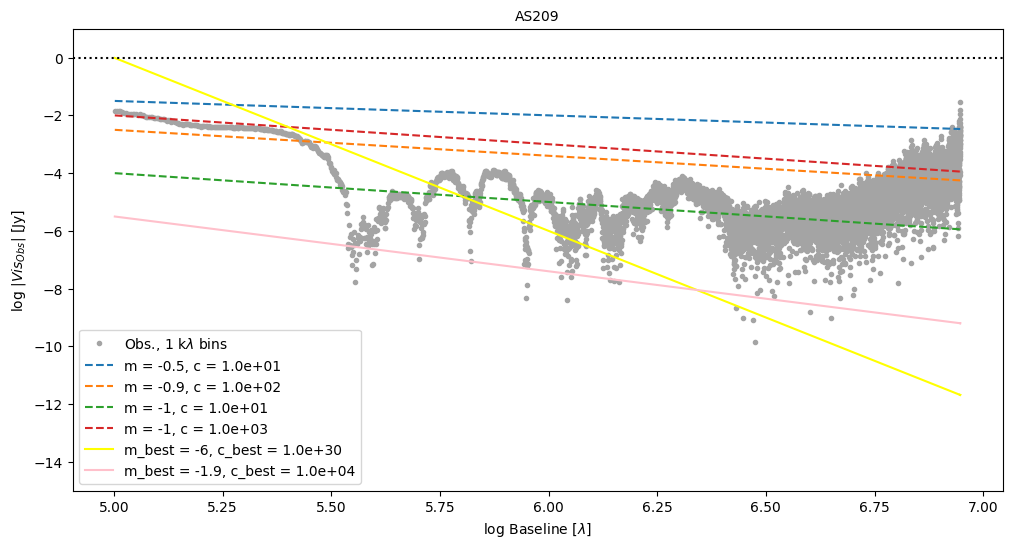

In [10]:
m_best1, c_best1 =  -6, 1e30
m_best2, c_best2 =  -1.9, 1e4 #-2, 1e8
m, c = -0.3, 60
m_array = [ -0.5, -0.9, -1, -1]#, -2, -2, -3, -3,  -3, -4,  -4, -4, -4]
c_array = [1e1, 1e2,  1e1,  1e3]# 1e5, 1e8, 1e5, 1e8, 1e13, 1e15,  1e19, 1e21, 1e22]
log_c_array = [1, 2, 1, 3]#, 5, 8, 5, 8, 13, 15, 19, 21, 22]

x = binned_vis.uv[100:]
y = np.abs(binned_vis.V[100:])**2

plt.clf()
plt.figure(figsize=(12, 6))
logy = np.log10(y)
logx = np.log10(x)
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
for i in range(0, len(m_array)):
    plt.plot(logx, linear(logx, m_array[i], c_array[i]), ls = '--', label = f'm = {m_array[i]}, c = {c_array[i]:.1e}')
plt.plot(logx, linear(logx, m_best1, c_best1), c = 'yellow', ls = '-', label = f'm_best = {m_best1}, c_best = {c_best1:.1e}')
plt.plot(logx, linear(logx, m_best2, c_best2), c = 'pink',  ls = '-',  label = f'm_best = {m_best2}, c_best = {c_best2:.1e}')

plt.axhline(0, c='black', ls=':')
plt.title( data_dic['disk_name'], size = 10)    
plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size = 10)
plt.legend(loc = 'best')
plt.ylim(-15, 1)
plt.show()

## Plotting with F1D

In [10]:
data = data_dic

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum_gridded_N200.txt"


# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
r_out = data['rout']

# Frank Parameters
N = 50
 # load data
u, v, Re, Im, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Im*1j

geom = Geometry(inc= inc, pa= pa, dra= dra, ddec= ddec)

In [11]:
import time
start_time = time.time()
FF = FourierBesselFitter(r_out, N, geom)
sol = FF.fit(u, v, Vis, Weights)
total_time = time.time() - start_time
print("--- %s minutes ---", total_time/60, " or ", total_time, " seconds.")

/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/optimization.py:381: RuntimeWarning: divide by zero encountered in log
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)
/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/optimization.py:381: RuntimeWarning: invalid value encountered in scalar multiply
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)


Minimum frequency in the data: 42971.83463481175
Maximum frequency in the data: 1519283.783515117
--- %s minutes --- 0.7706726511319478  or  46.24035906791687  seconds.


In [12]:
GM = FF._GaussianModel

## Plotting several

In [13]:
x_min, x_max = -4, 0
y_min, y_max = 0, 25

nx, ny = 20, 20
x = np.linspace(x_min, x_max, nx)
y = np.linspace(y_min, y_max, ny)
X, Y = np.meshgrid(x, y)

m_array = X.flatten()
log_c_array = Y.flatten()

In [14]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

In [15]:
# Caculating likelihood
import time

minus_log_likelihood_array = []
intensity_array = []

logdetS_array = []
logdetD_array = []
jTDj_array = []

start_time = time.time()
for i in range(0, len(m_array)):
    minus_log_likelihood, logdetS, logdetD, jTDj = GM.m_log_posterior([m_array[i], log_c_array[i]])
    minus_log_likelihood_array.append(minus_log_likelihood)
    logdetS_array.append(logdetS)
    logdetD_array.append(logdetD)
    jTDj_array.append(jTDj)
    intensity_array.append(GM.mean)
    print(f"for (m, log_c):({m_array[i]}, {log_c_array[i]}) with likelihood: {minus_log_likelihood: 2e}")

print("--- %s minutes ---" % (time.time()/60 - start_time/60))

......................................... Calculating likelihood with m, c, log(l):  -4.0 1.0 6
--- 9.06153917312622 seconds to calculate log_likelihood ---
for (m, log_c):(-4.0, 0.0) with likelihood:  1.371721e-05
......................................... Calculating likelihood with m, c, log(l):  -3.7894736842105265 1.0 6
--- 9.1059410572052 seconds to calculate log_likelihood ---
for (m, log_c):(-3.7894736842105265, 0.0) with likelihood:  1.494589e-04
......................................... Calculating likelihood with m, c, log(l):  -3.5789473684210527 1.0 6
--- 8.891403198242188 seconds to calculate log_likelihood ---
for (m, log_c):(-3.5789473684210527, 0.0) with likelihood:  1.638358e-03
......................................... Calculating likelihood with m, c, log(l):  -3.3684210526315788 1.0 6
--- 8.46464490890503 seconds to calculate log_likelihood ---
for (m, log_c):(-3.3684210526315788, 0.0) with likelihood:  1.854769e-02
......................................... Calculat

In [16]:
minus_log_likelihood_array = np.array(minus_log_likelihood_array)

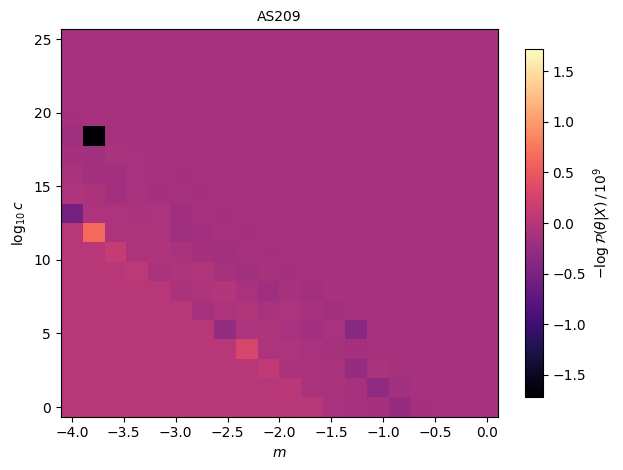

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

norm = colors.CenteredNorm()
Z = minus_log_likelihood_array.reshape(nx, ny)/1e9

plt.figure()
pcm = plt.pcolormesh(X, Y, Z, cmap="magma", norm=norm, shading="auto")
plt.xlabel(r"$m$")
plt.ylabel(r"$\log_{10} c$")
cbar = plt.colorbar(pcm, shrink=0.9)
cbar.set_label(r"$-\log \mathcal{P}(\theta | X) \,/\,10^9$")
plt.title( data_dic['disk_name'], size = 10)    


plt.tight_layout()
plt.show()

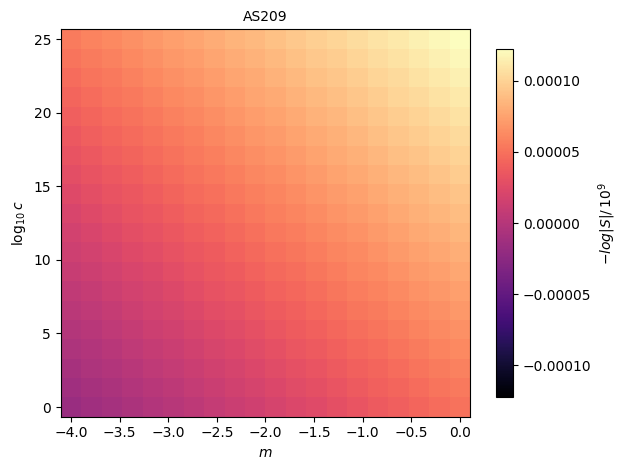

In [39]:
norm = colors.CenteredNorm()
Z = np.array(logdetS_array).reshape(nx, ny)/1e9


plt.figure()
pcm = plt.pcolormesh(X, Y, Z, cmap="magma", norm=norm, shading="auto")
plt.xlabel(r"$m$")
plt.ylabel(r"$\log_{10} c$")
cbar = plt.colorbar(pcm, shrink=0.9)
cbar.set_label(r"$-log|S|/\,10^9$")
plt.title(data_dic['disk_name'], size=10)

plt.tight_layout()
plt.show()


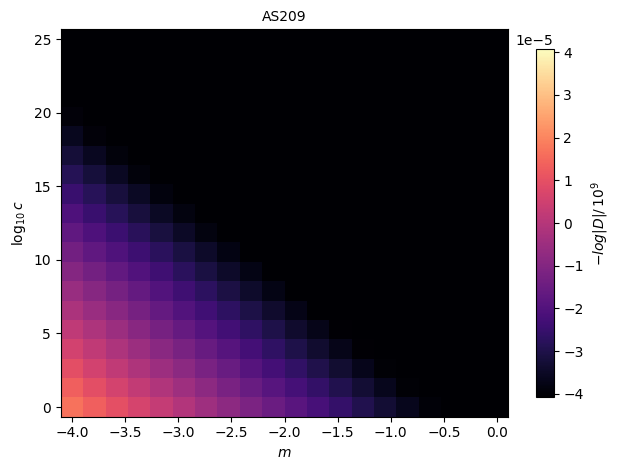

In [40]:
norm = colors.CenteredNorm()
Z = np.array(logdetD_array).reshape(nx, ny)/1e9


plt.figure()
pcm = plt.pcolormesh(X, Y, Z, cmap="magma", norm=norm, shading="auto")
plt.xlabel(r"$m$")
plt.ylabel(r"$\log_{10} c$")
cbar = plt.colorbar(pcm, shrink=0.9)
cbar.set_label(r"$-log|D|/\,10^9$")
plt.title(data_dic['disk_name'], size=10)

plt.tight_layout()
plt.show()

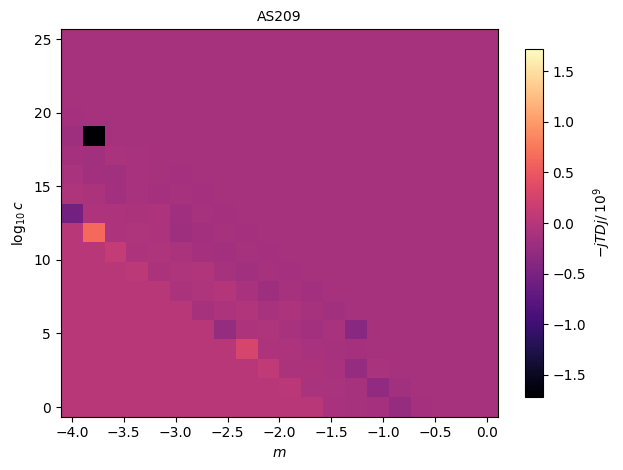

In [41]:
norm = colors.CenteredNorm()
Z = np.array(jTDj_array).reshape(nx, ny)/1e9


plt.figure()
pcm = plt.pcolormesh(X, Y, Z, cmap="magma", norm=norm, shading="auto")
plt.xlabel(r"$m$")
plt.ylabel(r"$\log_{10} c$")
cbar = plt.colorbar(pcm, shrink=0.9)
cbar.set_label(r"$-jTDj/\,10^9$")
plt.title(data_dic['disk_name'], size=10)

plt.tight_layout()
plt.show()

In [21]:
N = 50

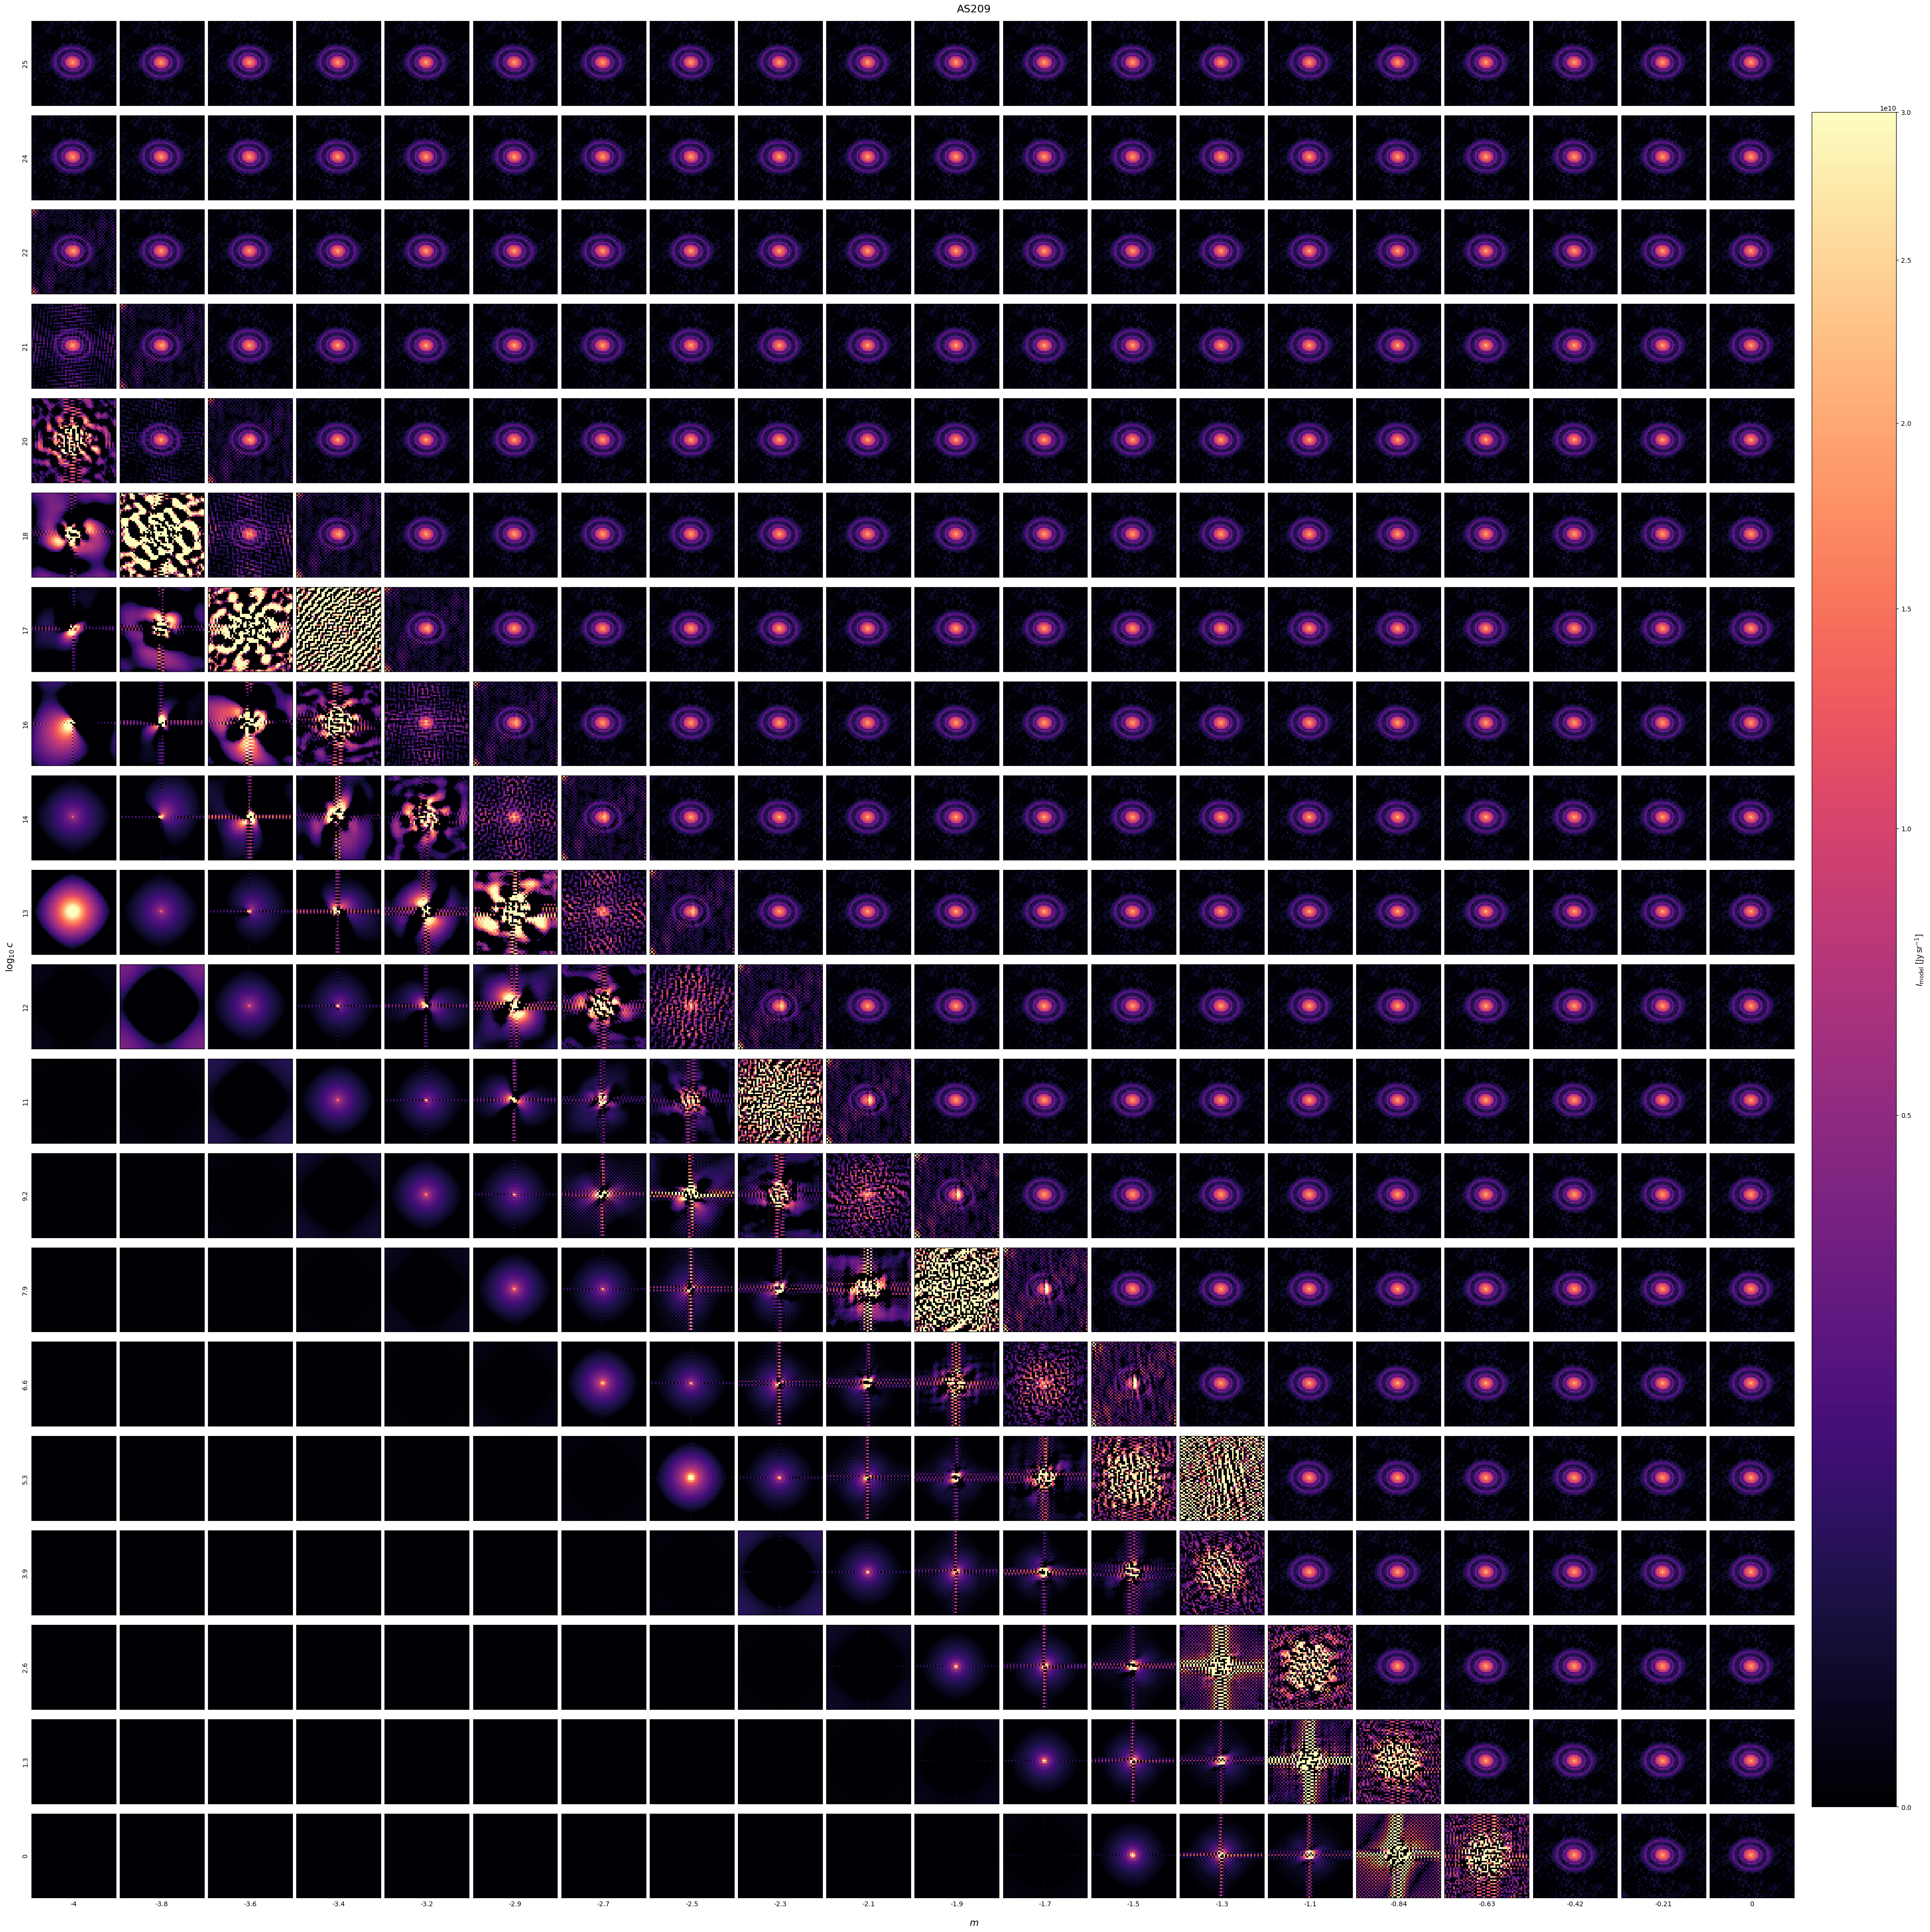

In [23]:
x_f1d = FF._DFT._Xn * rad_to_arcsec
y_f1d = FF._DFT._Yn * rad_to_arcsec

Xg = x_f1d.reshape(N, N)
Yg = y_f1d.reshape(N, N)

I_list = []
for I in intensity_array:
    I = np.asarray(I)
    if I.ndim == 1:
        I = I.reshape(N, N)
    elif I.shape != (N, N):
        raise ValueError(f"Mapa con forma {I.shape}, esperado {(N,N)}")
    I_list.append(I)

vmax = np.nanmax([np.nanmax(I) for I in I_list])
norm = colors.PowerNorm(gamma=0.5, vmin=0, vmax=3e10)


nrows, ncols = nx, ny
fig, axs = plt.subplots(nrows, ncols,
                        figsize=(2*ncols, 2*nrows),
                        constrained_layout=True)

axs = np.array(axs)  # shape (10,10)

for k, I in enumerate(I_list):
    row, col = divmod(k, ncols)
    row_inv = nrows - 1 - row
    ax = axs[row_inv, col]

    im = ax.pcolormesh(Xg, Yg, I, shading='auto', cmap="magma", norm=norm)
    ax.invert_xaxis()
    ax.set_aspect(1)

    ax.set_xticks([])
    ax.set_yticks([])


m_vals = np.unique(m_array.reshape(nrows, ncols)[0, :])        # columnas
logc_vals = np.unique(log_c_array.reshape(nrows, ncols)[:, 0]) # filas

for j, m_val in enumerate(m_vals):
    axs[-1, j].set_xlabel(f"{m_val:.2g}")

for i, logc_val in enumerate(logc_vals[::-1]):  # invertido porque reordenamos filas
    axs[i, 0].set_ylabel(f"{logc_val:.2g}")

fig.suptitle(data_dic['disk_name'] , fontsize=16)
fig.text(0.5, -0.008, r"$m$", ha="center", fontsize=14)
fig.text(-0.008, 0.5, r"$\log_{10} c$", va="center", rotation="vertical", fontsize=14)

cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.9, pad=0.01)
cbar.set_label(r"$I_{\mathrm{model}}\;[\mathrm{Jy}\,\mathrm{sr}^{-1}]$", size=12)

plt.show()

In [24]:
idx_min = np.argmin(minus_log_likelihood_array)
val_min = minus_log_likelihood_array[idx_min]

m_best = m_array[idx_min]
log_c_best = log_c_array[idx_min]
print(f"({m_best}, {log_c_best}) with - log posterior = {val_min}")

(-3.7894736842105265, 18.42105263157895) with - log posterior = -1722438408.4285483


In [25]:
idx_flat = np.argmin(Z)
i, j = np.unravel_index(idx_flat, Z.shape)
print(i, j)

14 1


## Plot the best fit

In [26]:
m_best, log_c_best = -5.130324014004792, 20.961411249760296

In [27]:
c_best = 10**(log_c_best)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_25519/1516205827.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-18, 0)


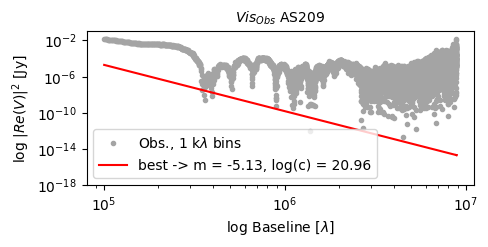

In [28]:
x = binned_vis.uv[100:]
y = np.abs(binned_vis.V[100:].real)**2

plt.figure(figsize=(5, 2))
plt.plot(x, y, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(x, power_spectrum(x, m_best, c_best), label = f'best -> m = {m_best:.2f}, log(c) = {log_c_best:.2f}', color = 'red')
plt.axhline(0, c='c', ls='-')
plt.title(r'$Vis_{Obs}$ '+ data_dic['disk_name'], size = 10)    
plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Re(V)|^{2}$ [Jy]', size = 10)
plt.xscale('log', base = 10)
plt.yscale('log', base = 10)
plt.ylim(1e-18, 0)
plt.legend(loc = 'best')
plt.show()

In [29]:
FF._GaussianModel.one_fit([m_best, log_c_best])

                 --------------> Fitting with m, c, log_l: -5.130324014004792 9.149792596074395e+20 6


In [30]:
GM.log_l

6

In [31]:
N = 50

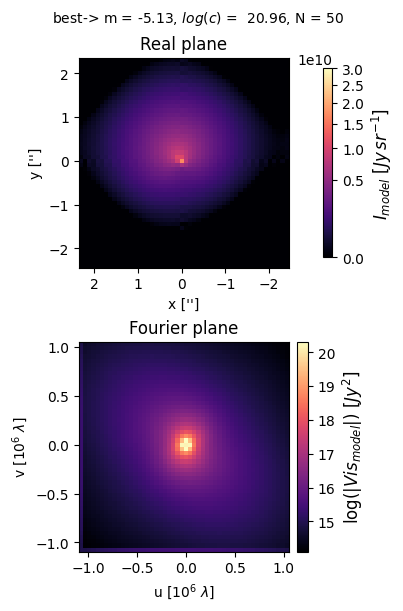

In [32]:
I = GM.mean
I_reshape = I.reshape(N, N)
r_out_rad = r_out

import matplotlib.colors as colors

x_f1d = FF._DFT._Xn * rad_to_arcsec
y_f1d = FF._DFT._Yn * rad_to_arcsec
u_f1d = FF._DFT._Un
v_f1d = FF._DFT._Vn

fig, axs = plt.subplots(2, 1, figsize=(4, 6), constrained_layout=True)  # 1 columna, 2 filas
# --- Panel 1: Real plane ---
norm = colors.PowerNorm(gamma=0.5, vmin=0, vmax = 3e10)

fig.suptitle(f'best-> m = {m_best:.2f}, $log(c) $ =  {log_c_best:.2f}, N = ' + str(N), fontsize=10)

plot1 = axs[0].pcolormesh(x_f1d.reshape(N, N),
                          y_f1d.reshape(N, N),
                          I_reshape, cmap="magma", norm=norm)
cbar1 = fig.colorbar(plot1, ax=axs[0], shrink = 0.9, pad=0.01)
cbar1.set_label(r'$I_{model}$ [$Jy\, sr^{-1}$]', size=12)
axs[0].invert_xaxis()
axs[0].set_title(r'Real plane')
axs[0].set_xlabel("x ['']")
axs[0].set_ylabel("y ['']")
axs[0].set_aspect(1)

# --- Panel 2: Fourier plane ---
plot2 = axs[1].pcolormesh(np.fft.fftshift(u_f1d.reshape(N, N))/1e6,
                          np.fft.fftshift(v_f1d.reshape(N, N))/1e6,
                          np.log(np.fft.fftshift(np.abs(np.fft.ifft2(I_reshape)))),
                          cmap="magma")
cbar2 = fig.colorbar(plot2, ax=axs[1], shrink = 1, pad=0.01)
cbar2.set_label(r'$\log(|Vis_{model}|)$ [$Jy^{2}$]', size=12)
axs[1].set_title(r'Fourier plane')
axs[1].set_xlabel(r'u [10$^{6}$ $\lambda$]')
axs[1].set_ylabel(r'v [10$^{6}$ $\lambda$]')
axs[1].set_aspect(1)

plt.show()

In [ ]:
sol = FF._sol

In [ ]:
from scipy.stats import binned_statistic

def get_vis_profile_binned(u, v, Vis, n_bins = 300, weighted = False):
    q = np.hypot(u, v)
    
    Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return q_centers, Vis_binned

In [ ]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]

baselines = np.hypot(u, v)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)

plt.figure(figsize=(14,5))

# Raw visibilities -------------------------------------------------------------------
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

#frank1d
u_f1d = FF._DFT._Un
v_f1d = FF._DFT._Vn

n_bins = 150
vis_fit_1d = sol.predict(u_f1d, v_f1d, I = sol.mean)
baselines_centers, vis_fit = get_vis_profile_binned(u_f1d, v_f1d, vis_fit_1d, n_bins = n_bins, weighted = True)
plt.plot(baselines_centers, np.abs(vis_fit), color = "blue", ls ='--', label = r'fit')

binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(0.5e-4, 1)
plt.xlim(1e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$V_{Model}$ F2D simulated in F1D with N = ' + str(N))
plt.legend(fontsize= 10)
plt.show()
